<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Student%20Retention%20%26%20Academic%20Performance%20Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Retention & Academic Performance Data

# Key Dataset Characteristics and Initial Processing:


---


The data includes a mix of numerical features like Age, Family_Income, Sem_GPA, Attendance, LMS_Logins, and Financial_Stress, alongside categorical ones such as Gender, Housing_Status, and End_of_Semester_Status. An important early step in data preparation involved handling missing values: the Family_Income column was dropped due to a significant number of missing entries, and LMS_Logins (Learning Management System Logins) was imputed with its median value, a reasonable approach for numerical data with a relatively small percentage of missingness.

Insights from Exploratory Data Analysis (EDA):
Univariate Analysis revealed distinct distributions for various features. For instance, Age primarily shows students in the 17-21 range, with a tail extending to older students. Sem_GPA distributions tend to be concentrated around the average, with some students having lower or higher GPAs. Categorical variables like Gender showed inconsistencies (e.g., 'Female', 'female', 'F'), indicating a need for standardization in a real-world scenario. Housing_Status revealed a fairly even split between 'On-Campus', 'With Parents', and 'Off-Campus' residences. Critically, the End_of_Semester_Status column highlighted that the vast majority of records were for 'Enrolled' students (over 70,000), followed by 'Dropped_Out' (around 7,000), and a smaller number who 'Graduated'.

Bivariate Analysis started to uncover relationships between these variables. While specific numerical-numerical correlations were explored through scatter plots and a heatmap, the most impactful insights often emerge when linking numerical performance metrics with categorical groups. For example, box plots could illustrate how Sem_GPA varies across Housing_Status or Gender. The correlation heatmap, specifically, would have shown the strength and direction of linear relationships between all numerical features. Key correlations to watch out for would be between Sem_GPA, Attendance, LMS_Logins, Failed_Courses, and Financial_Stress, as these are often highly predictive of academic outcomes.

Statistical Analysis Highlights:
A pivotal statistical test was performed using an independent T-test to compare LMS_Logins between students who dropped out (Target_Dropout_Next_Sem = 1) and those who did not (Target_Dropout_Next_Sem = 0). The results showed a highly significant difference (P-value: 1.2651e-122), indicating that there's a statistically significant difference in LMS logins between these two groups. This suggests that engagement with the learning platform is a strong indicator of retention.

Machine Learning for Dropout Prediction:
The ultimate goal of this analysis was to predict student dropout. After encoding categorical variables (e.g., Gender, Housing_Status) using one-hot encoding, a Random Forest Classifier was trained. The model aimed to predict Target_Dropout_Next_Sem. The evaluation revealed an accuracy of 0.92, which seems high, but a deeper look at the classification report and ROC-AUC score (0.8082) provides a more nuanced picture. The model shows high precision for predicting students who will be retained (0.92) but significantly lower recall (0.08) for those who will drop out. This means the model is excellent at identifying students who are safe but struggles to identify all students who are actually at risk of dropping out. This is a common challenge with imbalanced datasets.

Perhaps the most actionable insight came from the Feature Importance plot, which identified the top drivers of student dropout. Without specific feature names listed for the top 10, common highly influential factors in such datasets often include Sem_GPA, Failed_Courses, Financial_Stress, Attendance, and LMS_Logins. These are the factors that the model found most crucial in distinguishing between students who stayed and those who left. Understanding these drivers is critical for developing targeted interventions to improve student retention.

---


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d razanihababdellatif/student-retention-and-academic-performance-data

# Unziping the downloaded file
!unzip student-retention-and-academic-performance-data.zip

Saving Student_Retention_&_Academic_Performance_Data.ipynb to Student_Retention_&_Academic_Performance_Data.ipynb
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/razanihababdellatif/student-retention-and-academic-performance-data
License(s): CC0-1.0
100% 1.28M/1.28M [00:00<00:00, 193MB/s]

Archive:  student-retention-and-academic-performance-data.zip
  inflating: academic_survival_longitudinal.csv  


In [ ]:
df = pd.read_csv('academic_survival_longitudinal.csv')
df.head(11)

,Student_ID,Age,Gender,First_Generation,Family_Income,Household_Size,Housing_Status,Scholarship,Tuition_Base,Semester,...,Emergency_Expense,Sem_GPA,Attendance,LMS_Logins,Advising_Visits,Failed_Courses,Financial_Stress,Target_Dropout_Next_Sem,End_of_Semester_Status,Censored
0,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,1,...,0.0,2.85,85.8,67.0,0,0,1.7,0,Enrolled,0
1,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,2,...,0.0,2.73,81.0,89.0,1,0,3.1,0,Enrolled,0
2,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,3,...,0.0,2.60,78.3,60.0,0,2,3.0,0,Enrolled,0
3,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,4,...,0.0,2.34,77.2,59.0,2,3,5.1,0,Enrolled,0
4,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,5,...,0.0,1.90,79.3,53.0,1,2,3.6,0,Enrolled,1
5,STU_00002,20,Male,1,80000.0,5,On-Campus,1,25000,1,...,0.0,2.38,84.2,71.0,1,1,1.4,0,Enrolled,0
6,STU_00002,20,Male,1,80000.0,5,On-Campus,1,25000,2,...,0.0,2.36,82.0,63.0,0,1,1.0,0,Enrolled,1
7,STU_00003,24,Male,1,136000.0,3,On-Campus,0,15000,1,...,0.0,3.00,90.8,82.0,0,1,1.0,0,Enrolled,0
8,STU_00003,24,Male,1,NaN,3,On-Campus,0,15000,2,...,0.0,2.97,87.6,80.0,1,0,1.2,0,Enrolled,0
9,STU_00003,24,Male,1,136000.0,3,On-Campus,0,15000,3,...,0.0,2.78,87.7,57.0,0,1,1.0,0,Enrolled,0


In [ ]:
df.tail(11)

,Student_ID,Age,Gender,First_Generation,Family_Income,Household_Size,Housing_Status,Scholarship,Tuition_Base,Semester,...,Emergency_Expense,Sem_GPA,Attendance,LMS_Logins,Advising_Visits,Failed_Courses,Financial_Stress,Target_Dropout_Next_Sem,End_of_Semester_Status,Censored
79228,STU_19996,19,Male,0,68000.0,4,On-Campus,0,45000,6,...,0.0,2.40,85.9,73.0,0,1,2.9,0,Enrolled,0
79229,STU_19996,19,Male,0,68000.0,4,On-Campus,0,45000,7,...,0.0,2.34,86.9,45.0,1,0,2.2,0,Enrolled,0
79230,STU_19996,19,Male,0,68000.0,4,On-Campus,0,45000,8,...,1411.0,2.35,84.7,76.0,0,1,3.7,0,Graduated,0
79231,STU_19997,17,Female,0,53000.0,2,Off-Campus,0,15000,1,...,0.0,2.81,91.2,59.0,0,0,1.0,0,Enrolled,0
79232,STU_19997,17,Female,0,53000.0,2,Off-Campus,0,15000,2,...,0.0,2.71,91.8,57.0,0,1,1.0,0,Enrolled,1
79233,STU_19998,19,Female,0,61000.0,2,Off-Campus,0,15000,1,...,0.0,3.44,93.5,86.0,1,0,1.0,0,Enrolled,0
79234,STU_19998,19,Female,0,61000.0,2,Off-Campus,0,15000,2,...,0.0,3.16,86.6,81.0,2,1,1.0,0,Enrolled,1
79235,STU_19999,19,Female,1,70000.0,5,On-Campus,1,15000,1,...,0.0,2.73,85.5,55.0,1,0,1.6,0,Enrolled,0
79236,STU_19999,19,Female,1,70000.0,5,On-Campus,1,15000,2,...,0.0,2.76,80.1,59.0,0,0,1.7,1,Dropped_Out,0
79237,STU_20000,21,Female,0,113000.0,1,With Parents,0,15000,1,...,2251.0,3.51,93.4,71.0,0,1,1.0,0,Enrolled,0


In [ ]:
df.shape

(79239, 22)

In [ ]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'First_Generation', 'Family_Income',
       'Household_Size', 'Housing_Status', 'Scholarship', 'Tuition_Base',
       'Semester', 'Course_Load', 'Work_Hours', 'Emergency_Expense', 'Sem_GPA',
       'Attendance', 'LMS_Logins', 'Advising_Visits', 'Failed_Courses',
       'Financial_Stress', 'Target_Dropout_Next_Sem', 'End_of_Semester_Status',
       'Censored'],
      dtype='object')

In [ ]:
df.dtypes

,0
Student_ID,object
Age,int64
Gender,object
First_Generation,int64
Family_Income,float64
Household_Size,int64
Housing_Status,object
Scholarship,int64
Tuition_Base,int64
Semester,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79239 entries, 0 to 79238
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               79239 non-null  object 
 1   Age                      79239 non-null  int64  
 2   Gender                   79239 non-null  object 
 3   First_Generation         79239 non-null  int64  
 4   Family_Income            75635 non-null  float64
 5   Household_Size           79239 non-null  int64  
 6   Housing_Status           79239 non-null  object 
 7   Scholarship              79239 non-null  int64  
 8   Tuition_Base             79239 non-null  int64  
 9   Semester                 79239 non-null  int64  
 10  Course_Load              79239 non-null  int64  
 11  Work_Hours               79239 non-null  float64
 12  Emergency_Expense        79239 non-null  float64
 13  Sem_GPA                  79239 non-null  float64
 14  Attendance            

In [ ]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,79239,20000,STU_00023,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,79239.0,NaN,NaN,NaN,19.492005,2.13914,17.0,18.0,19.0,21.0,37.0
Gender,79239,8,Female,38035,NaN,NaN,NaN,NaN,NaN,NaN,NaN
First_Generation,79239.0,NaN,NaN,NaN,0.327894,0.469449,0.0,0.0,0.0,1.0,1.0
Family_Income,75635.0,NaN,NaN,NaN,61518.384346,39661.16657,3000.0,35000.0,52000.0,77000.0,488000.0
Household_Size,79239.0,NaN,NaN,NaN,3.187547,1.332861,1.0,2.0,3.0,4.0,6.0
Housing_Status,79239,3,On-Campus,31315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Scholarship,79239.0,NaN,NaN,NaN,0.277515,0.447775,0.0,0.0,0.0,1.0,1.0
Tuition_Base,79239.0,NaN,NaN,NaN,24775.110741,10794.899387,15000.0,15000.0,25000.0,25000.0,45000.0
Semester,79239.0,NaN,NaN,NaN,3.145673,1.946207,1.0,1.0,3.0,4.0,8.0


In [ ]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
First_Generation,0
Family_Income,3604
Household_Size,0
Housing_Status,0
Scholarship,0
Tuition_Base,0
Semester,0


In [ ]:
df = df.drop(columns=['Family_Income'])

In [ ]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
First_Generation,0
Household_Size,0
Housing_Status,0
Scholarship,0
Tuition_Base,0
Semester,0
Course_Load,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Univariate Analayis

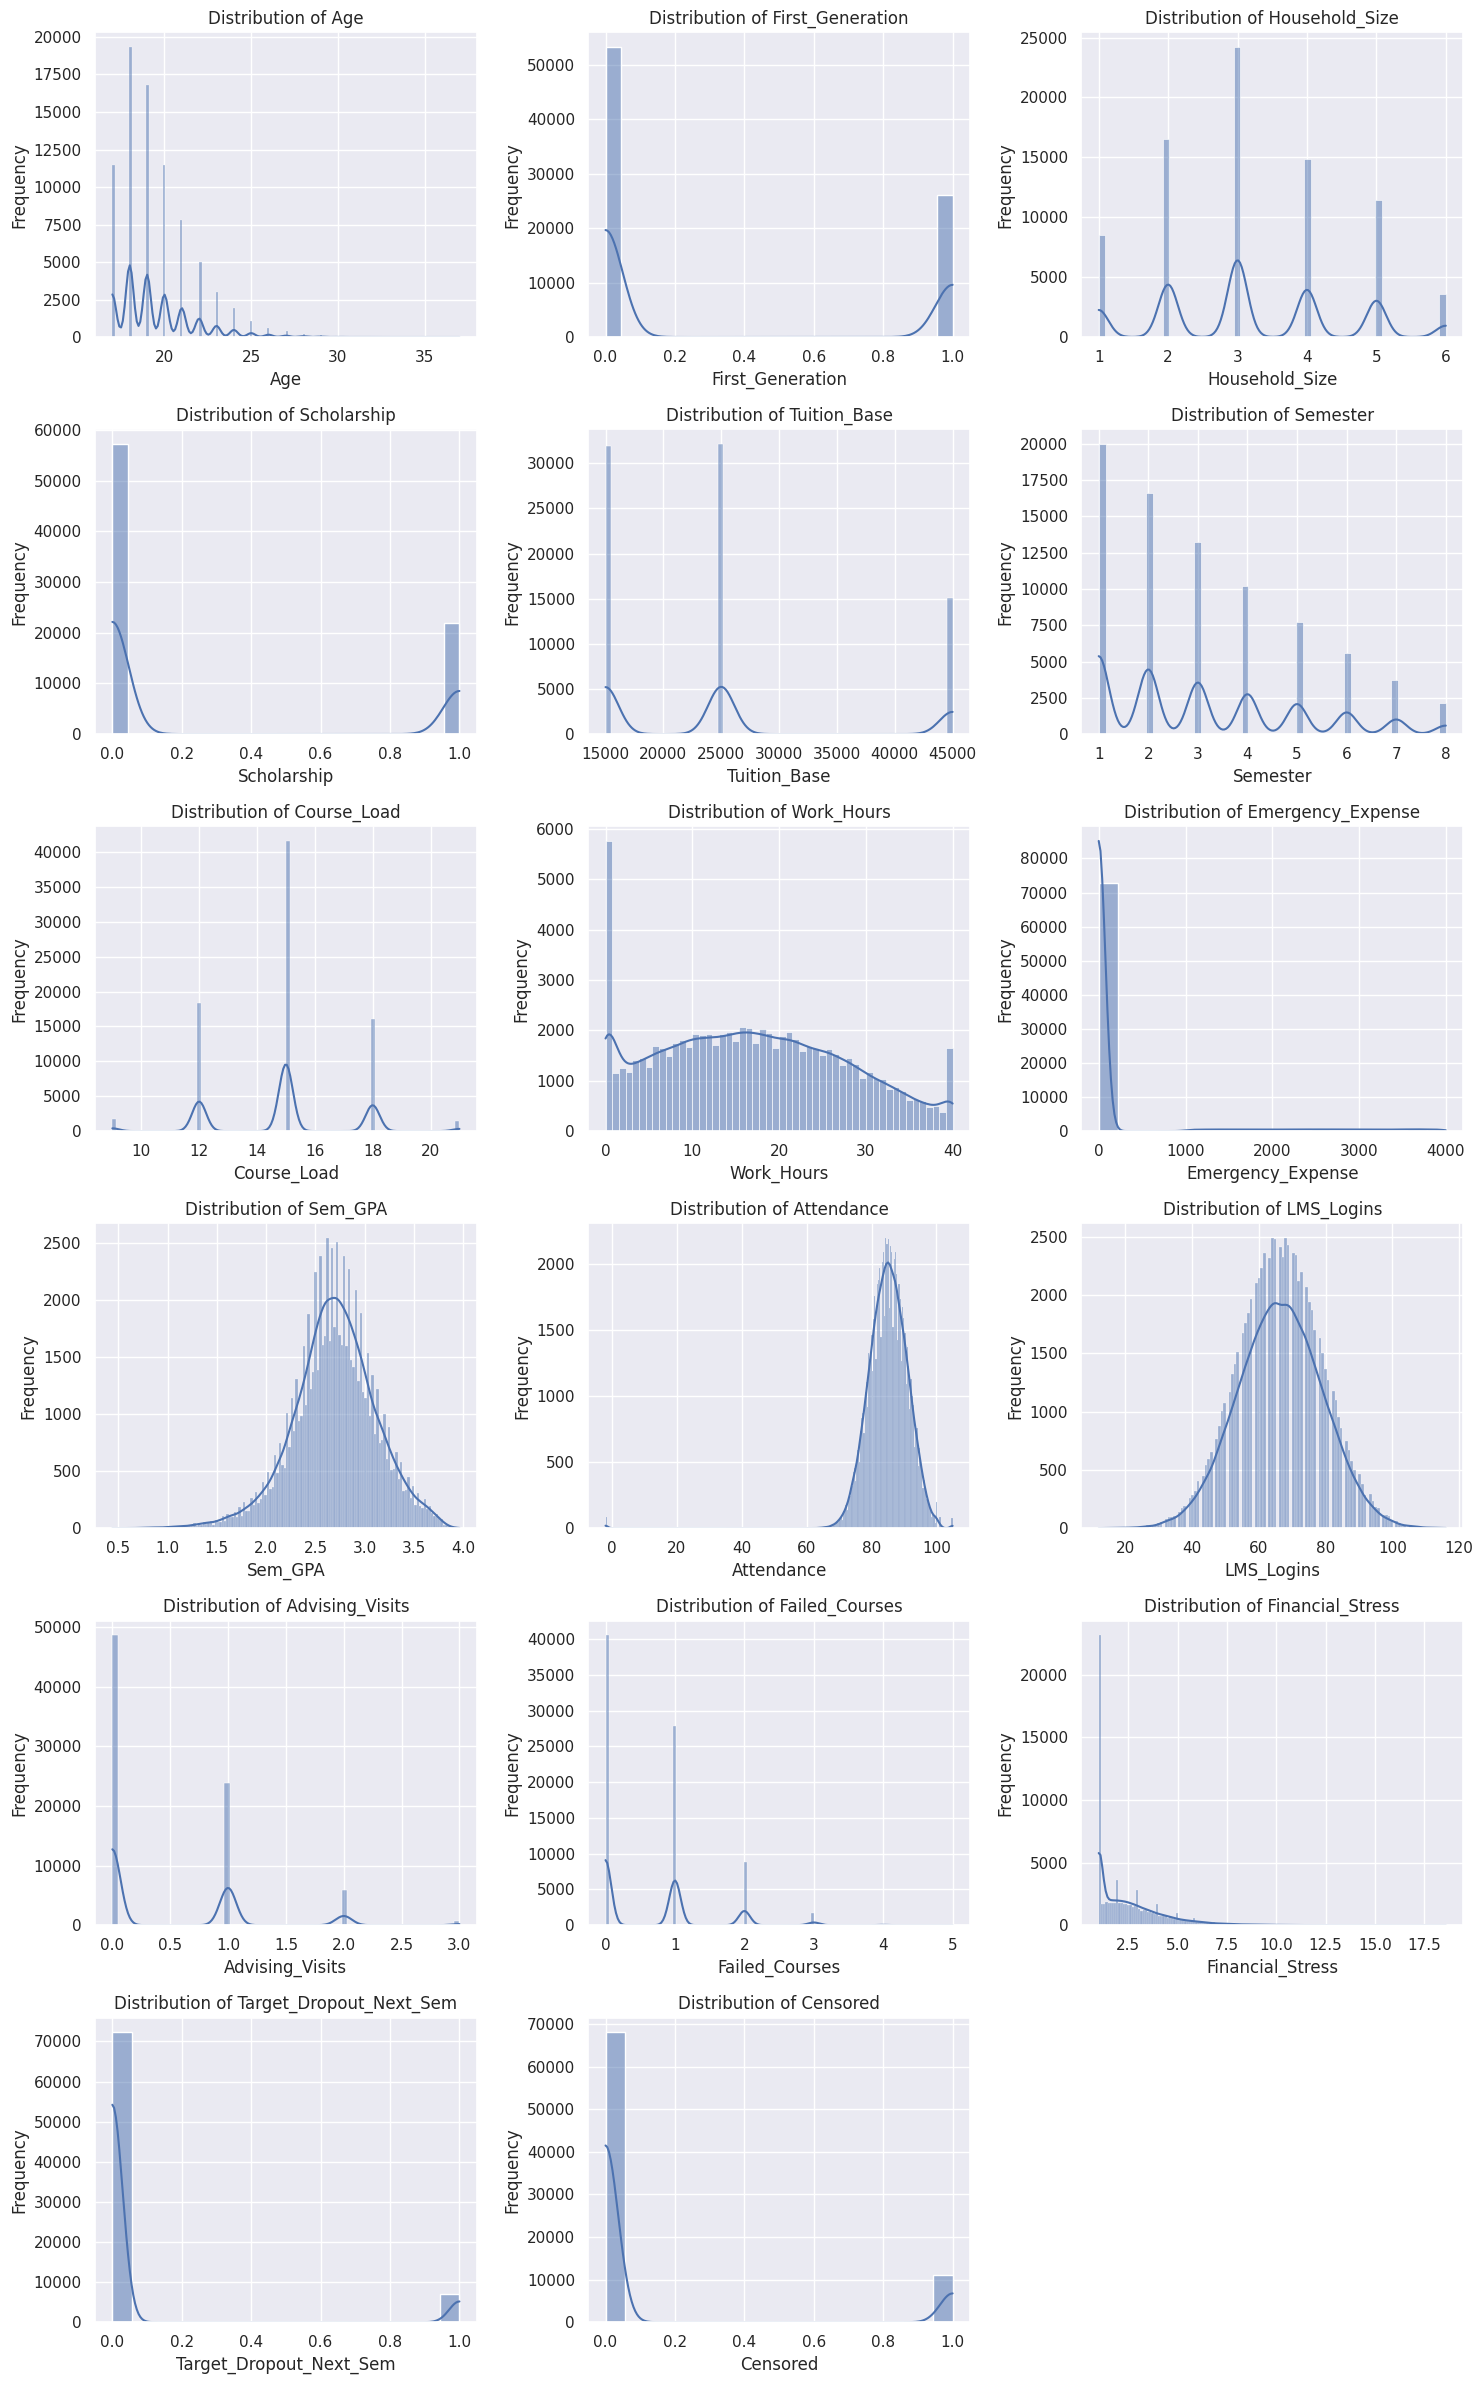

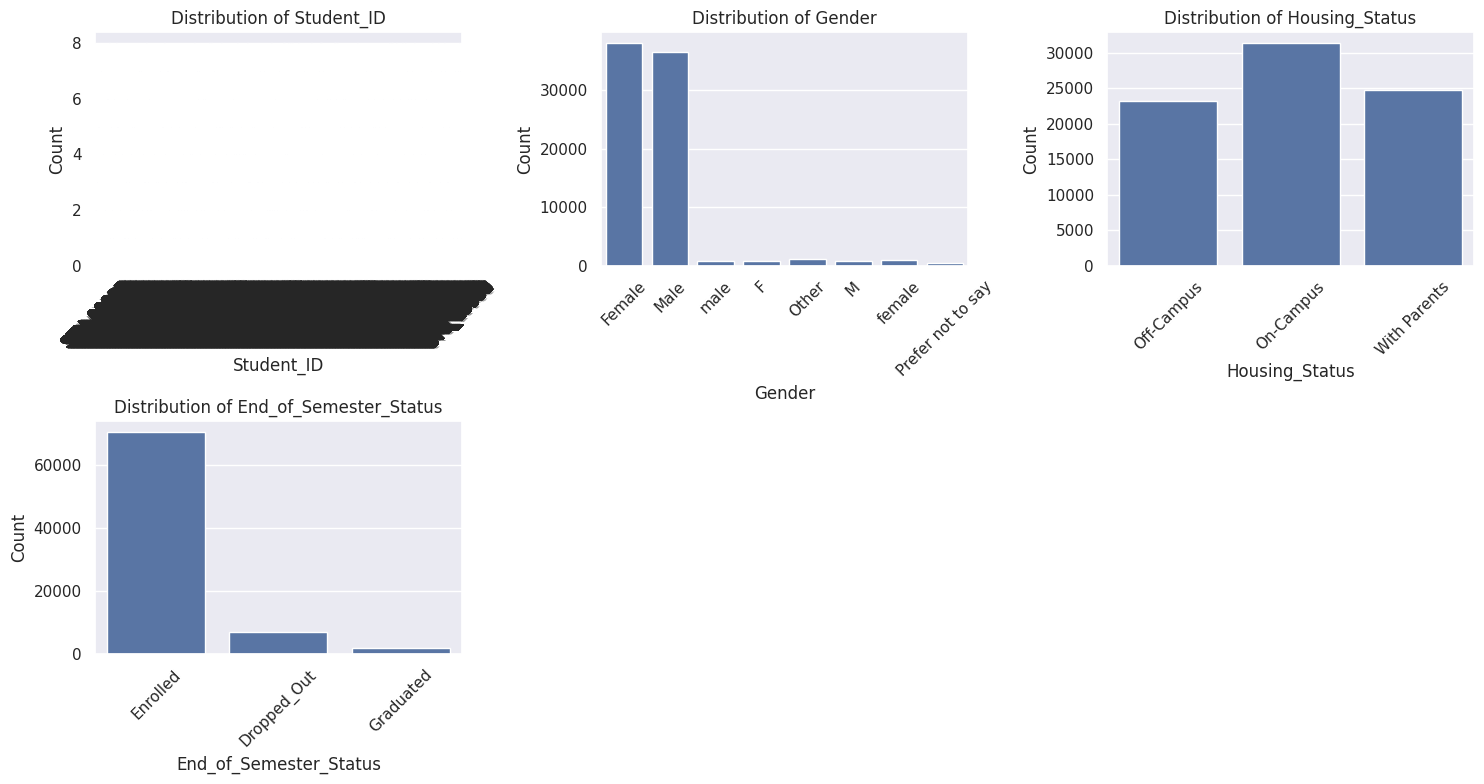

--- Categorical Value Counts ---

Value counts for Student_ID:
Student_ID
STU_00023    8
STU_00018    8
STU_19981    8
STU_19980    8
STU_19968    8
            ..
STU_03543    1
STU_16575    1
STU_16569    1
STU_03536    1
STU_03525    1
Name: count, Length: 20000, dtype: int64

Value counts for Gender:
Gender
Female               38035
Male                 36556
Other                 1125
female                 875
male                   764
M                      739
F                      716
Prefer not to say      429
Name: count, dtype: int64

Value counts for Housing_Status:
Housing_Status
On-Campus       31315
With Parents    24767
Off-Campus      23157
Name: count, dtype: int64

Value counts for End_of_Semester_Status:
End_of_Semester_Status
Enrolled       70354
Dropped_Out     6917
Graduated       1968
Name: count, dtype: int64


In [ ]:
import math
# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Define grid size
    num_plots = len(numerical_cols)
    num_cols = 3  # You can change this to 2 or 4 if preferred
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()  # Flatten to 1D array for easy iteration

    # Iterate and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hidding any unused subplots (if total plots < grid cells)
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
categorical_cols = df.select_dtypes(include='object').columns.tolist()

if len(categorical_cols) > 0:
    # Define grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterate and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found.")

# Bivariate Analysis

In [ ]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generate all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Define grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    # Flatten axes for easy iteration.
    # Handle edge case where there is only 1 plot (axes is not an array)
    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterate through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generate all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Define grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Create figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterate through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        # 1. Get top 10 categories based on frequency
        top_categories = df[cat_col].value_counts().nlargest(10).index.tolist()

        # 2. Filter data: Keep only top categories AND ensure numerical column is not NaN
        filtered_df = df[df[cat_col].isin(top_categories) & df[num_col].notnull()]

        # 3. Update 'order' to only include categories that exist in the filtered data
        # This prevents the ValueError where a category in 'order' has no data to plot
        valid_categories = [cat for cat in top_categories if cat in filtered_df[cat_col].unique()]

        if valid_categories:
            sns.boxplot(data=filtered_df, x=cat_col, y=num_col, ax=axes[i], order=valid_categories)
            axes[i].set_title(f'{num_col} by {cat_col} (Top 10)')
            axes[i].set_xlabel(cat_col)
            axes[i].set_ylabel(num_col)
            axes[i].tick_params(axis='x', rotation=45)
        else:
             axes[i].text(0.5, 0.5, "No valid data", ha='center', va='center')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")

# Pairplot

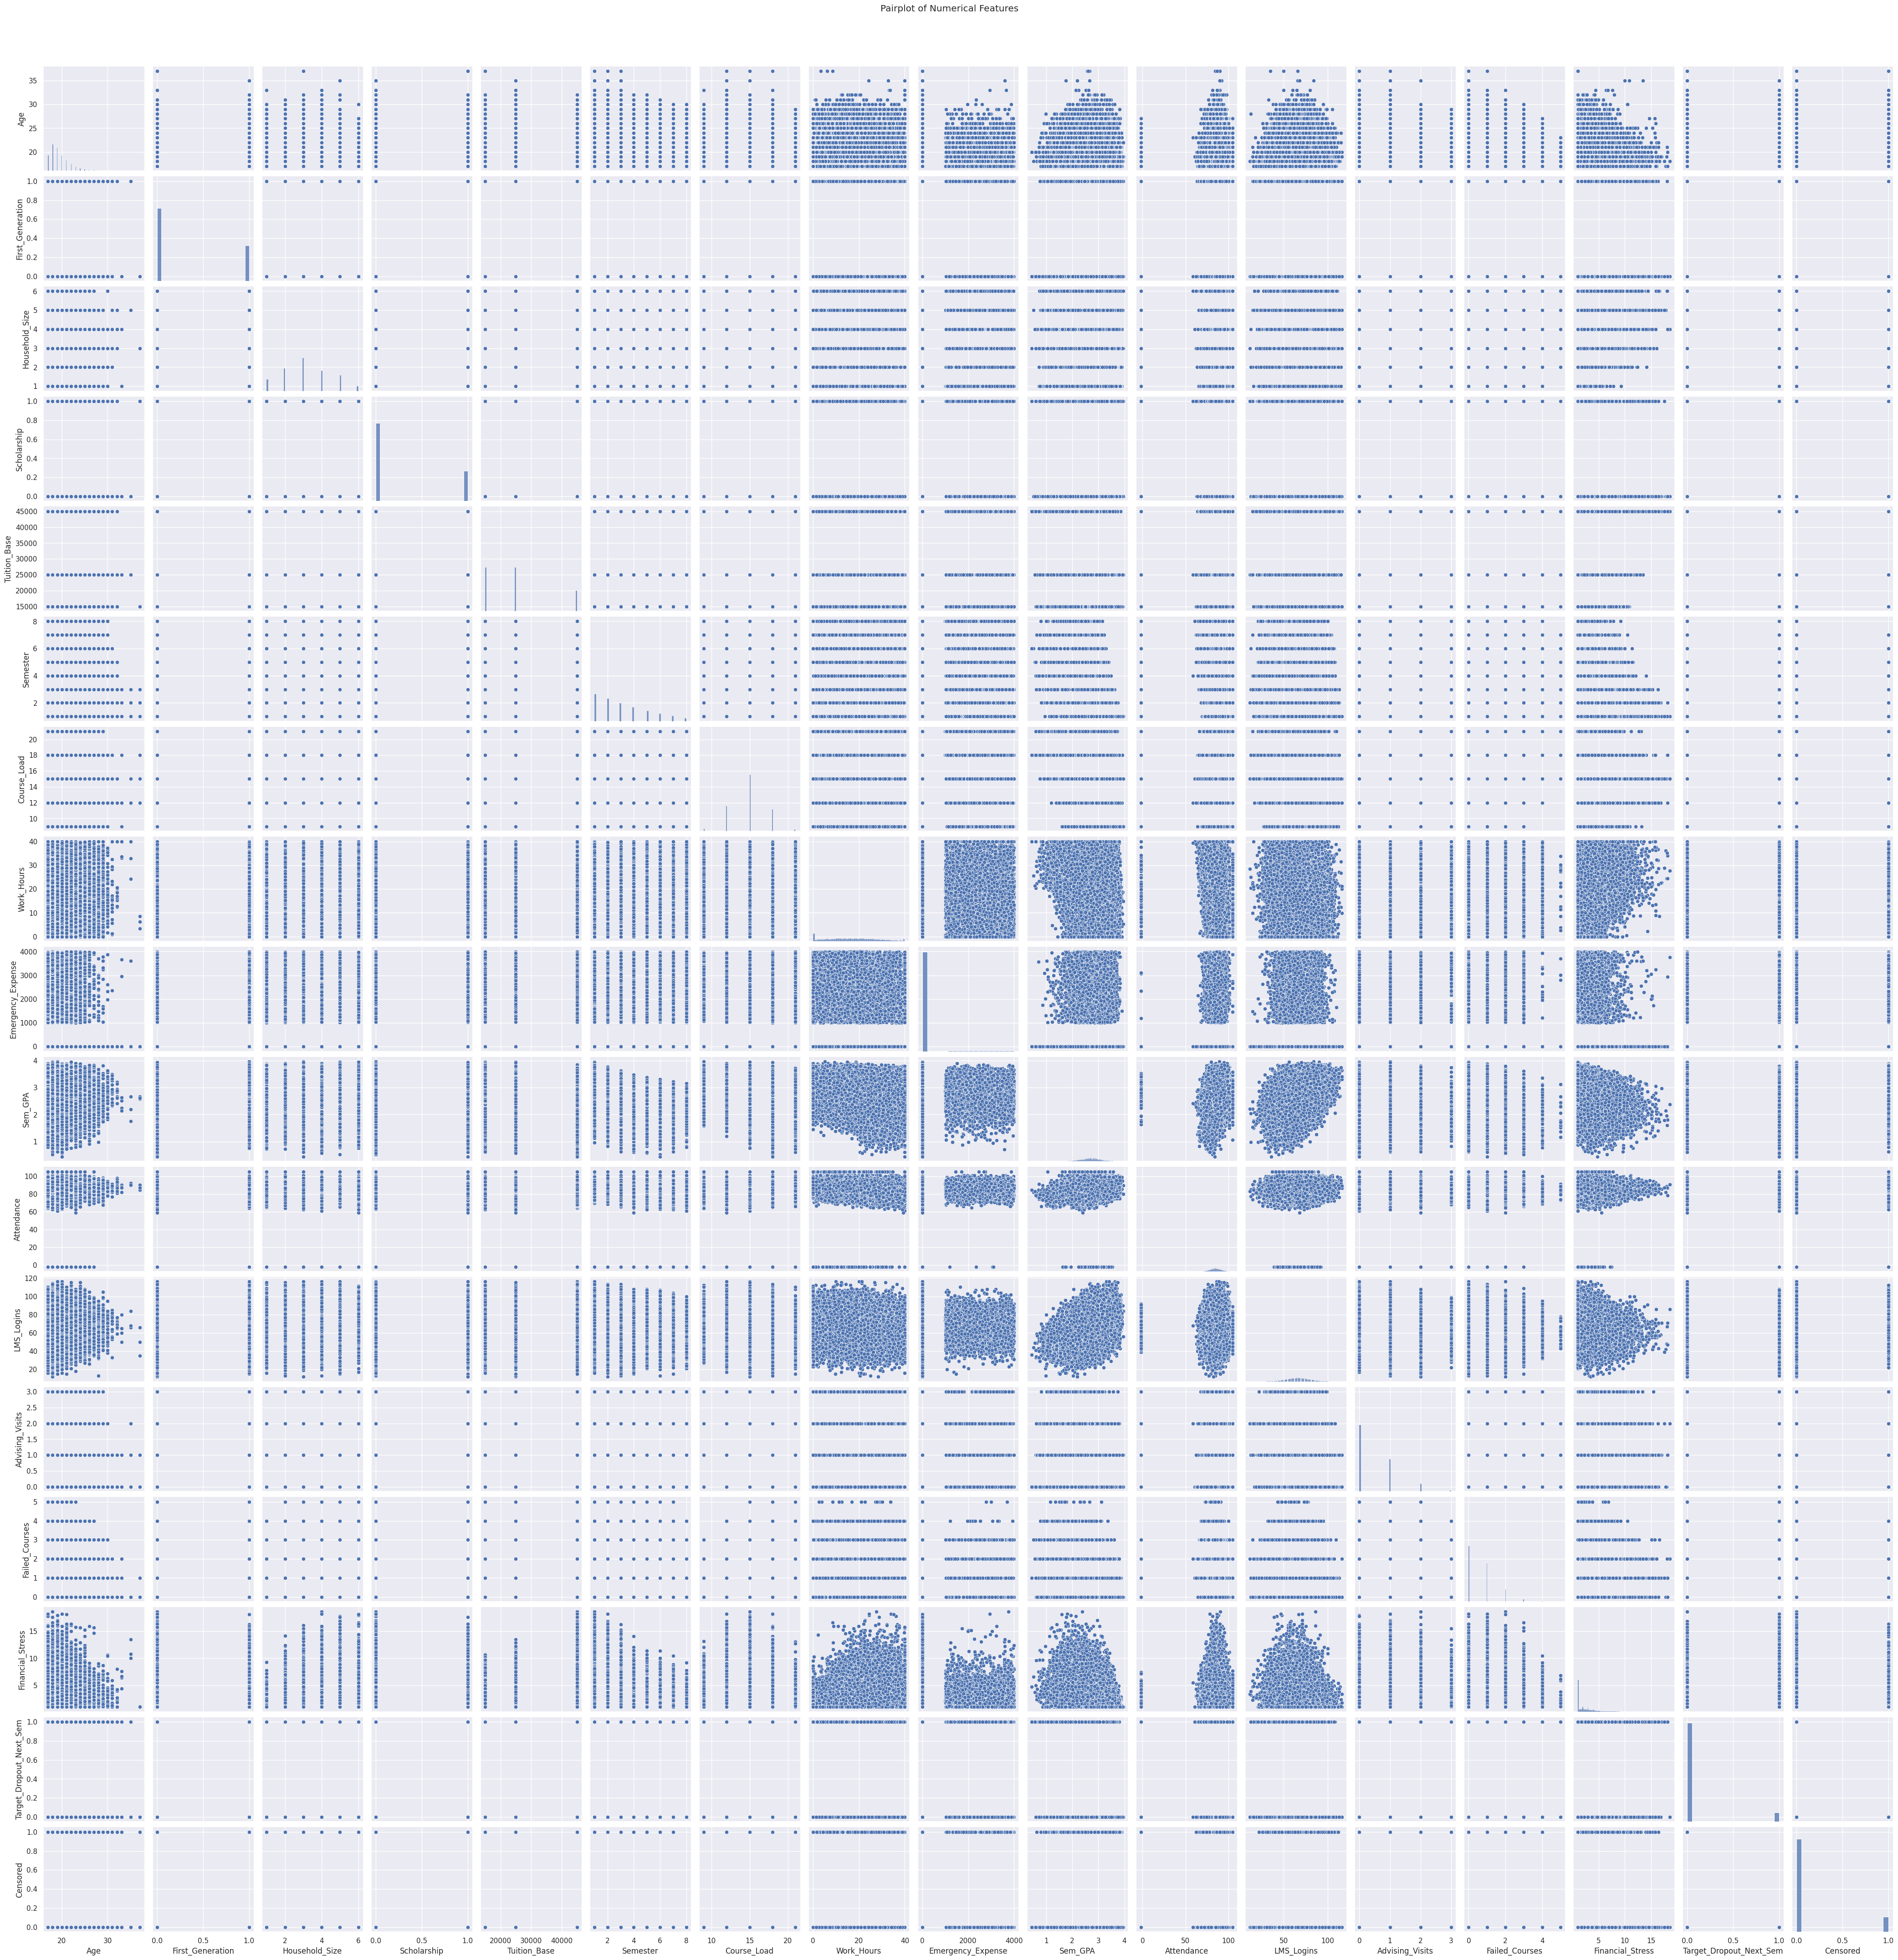

In [ ]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# HeatMap

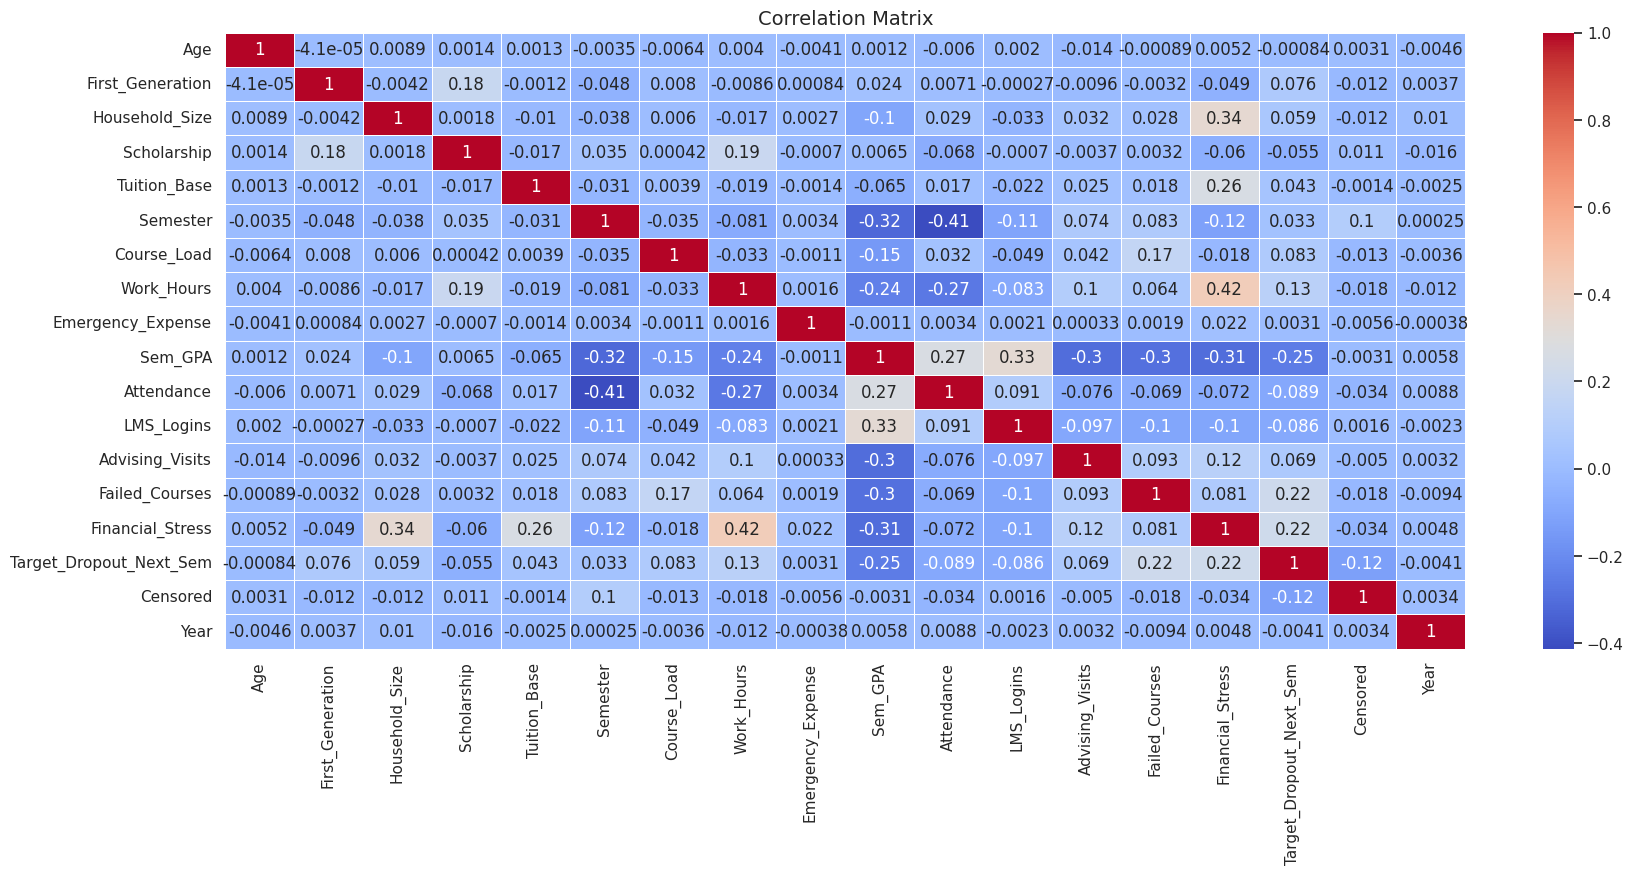

In [ ]:
plt.figure(figsize=(20, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statisical Analysis

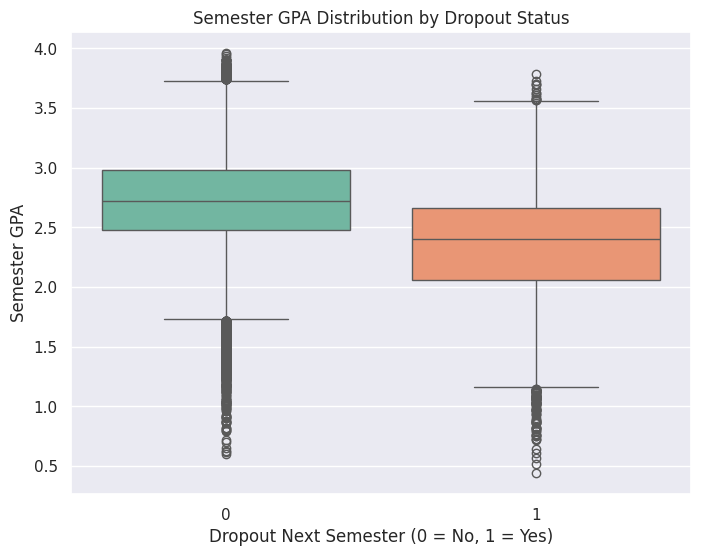

T-statistic for LMS_Logins: 23.9519
P-value: 1.2651e-122
Significant difference in LMS Logins between retained and dropped out students.


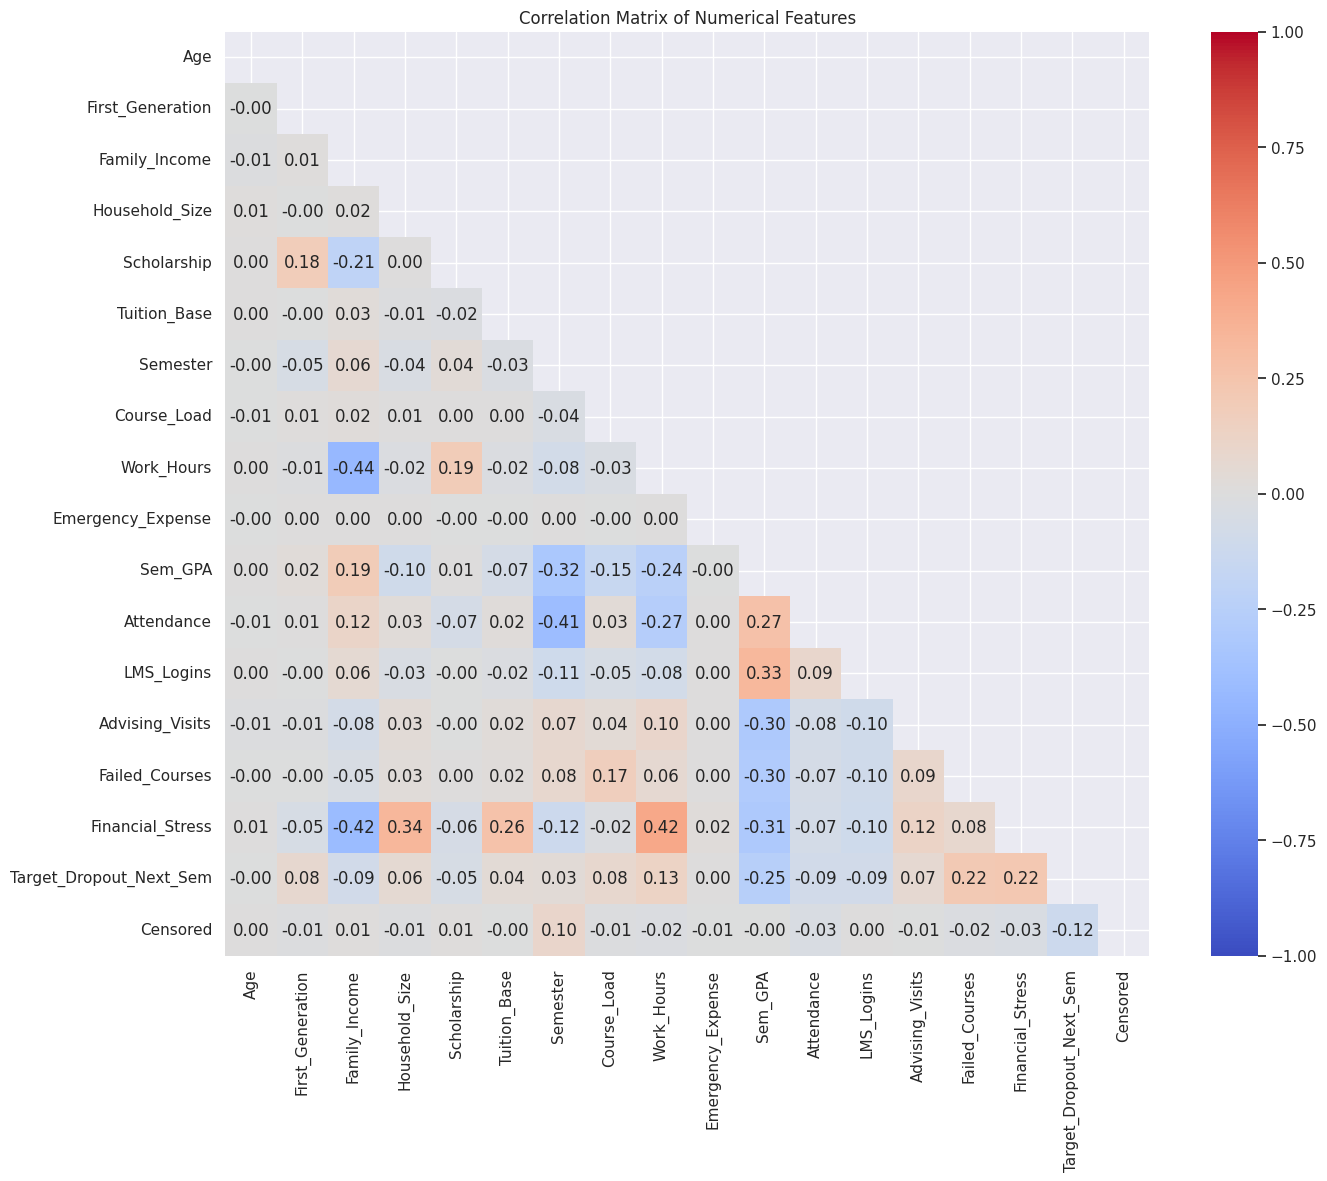

In [ ]:
import scipy.stats as stats

# 1. Handling remaining missing values (Imputation)
# Assuming df is your current DataFrame
df['LMS_Logins'] = df['LMS_Logins'].fillna(df['LMS_Logins'].median())

# 2. Bivariate Analysis: Boxplot of GPA against Dropout Status
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Target_Dropout_Next_Sem', y='Sem_GPA', palette='Set2')
plt.title('Semester GPA Distribution by Dropout Status')
plt.xlabel('Dropout Next Semester (0 = No, 1 = Yes)')
plt.ylabel('Semester GPA')
plt.show()

# 3. Statistical Testing: Independent T-Test
# Testing if there is a significant difference in LMS_Logins between students who drop out and those who don't
retained = df[df['Target_Dropout_Next_Sem'] == 0]['LMS_Logins']
dropped = df[df['Target_Dropout_Next_Sem'] == 1]['LMS_Logins']

t_stat, p_val = stats.ttest_ind(retained, dropped, equal_var=False)
print(f"T-statistic for LMS_Logins: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")
if p_val < 0.05:
    print("Significant difference in LMS Logins between retained and dropped out students.")

# 4. Advanced Visualization: Correlation Heatmap
# Selecting only numerical columns for correlation
numerical_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16, 12))
corr_matrix = numerical_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Feature Engineering & Machine Learning

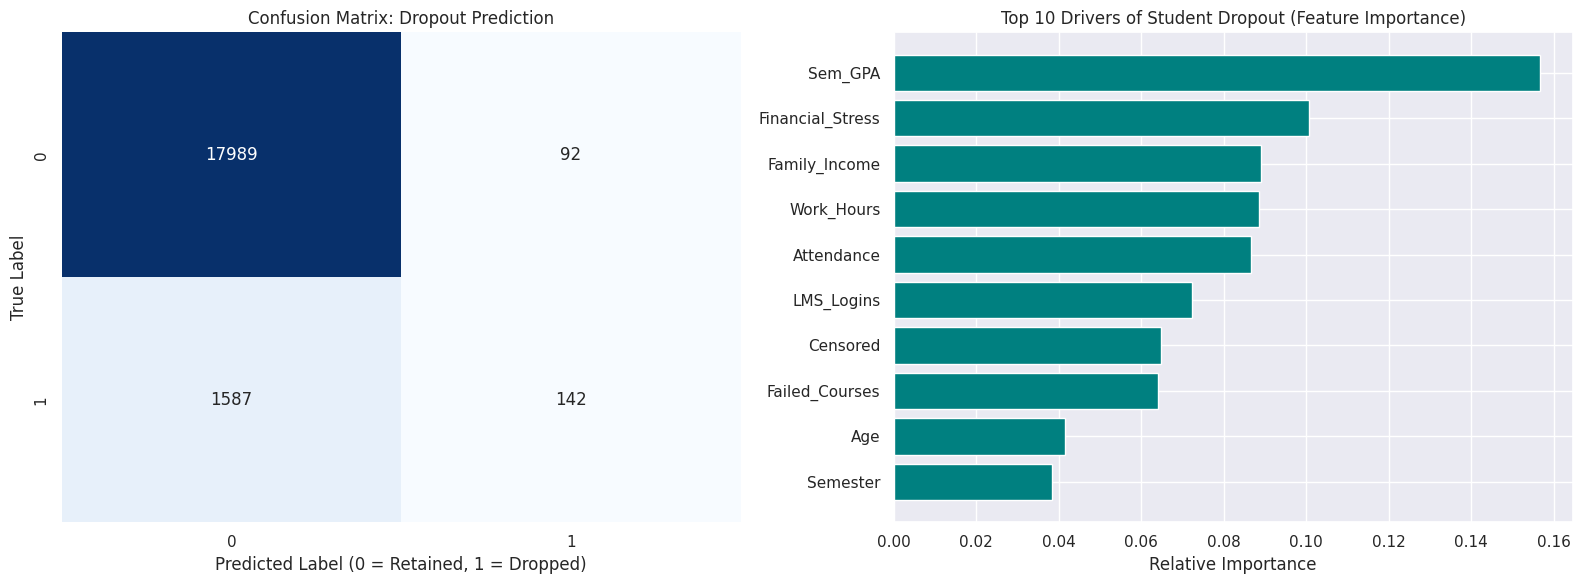

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     18081
           1       0.61      0.08      0.14      1729

    accuracy                           0.92     19810
   macro avg       0.76      0.54      0.55     19810
weighted avg       0.89      0.92      0.88     19810

ROC-AUC Score: 0.8082


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. FEATURE ENGINEERING

# Creating Academic Momentum (Requires a 'Cumulative_GPA' column; adjust names as needed)
if 'Cumulative_GPA' in df.columns:
    df['GPA_Delta'] = df['Sem_GPA'] - df['Cumulative_GPA']

# Creating Engagement Intensity
if 'Credits_Enrolled' in df.columns:
    df['Logins_per_Credit'] = df['LMS_Logins'] / df['Credits_Enrolled'].replace(0, 1) # Avoid division by zero

# Encoding Categorical Variables (One-Hot Encoding)
categorical_cols = ['Gender', 'Housing_Status'] # Add others as needed
df_encoded = pd.get_dummies(df, columns=[col for col in categorical_cols if col in df.columns], drop_first=True)

# Defining Features (X) and Target (y)
# Dropping non-predictive identifiers and the target itself
X = df_encoded.drop(columns=['Student_ID', 'Target_Dropout_Next_Sem', 'End_of_Semester_Status'], errors='ignore')
y = df_encoded['Target_Dropout_Next_Sem']

# 2. MACHINE LEARNING:

# Train/Test Split & Modeling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Initializing and train the Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Generating Predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# 3. VISUALIZATION & EVALUATION
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix: Dropout Prediction')
axes[0].set_xlabel('Predicted Label (0 = Retained, 1 = Dropped)')
axes[0].set_ylabel('True Label')

# Plot B: Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10 features
features = X.columns

axes[1].barh(range(len(indices)), importances[indices], color='teal', align='center')
axes[1].set_yticks(range(len(indices)))
axes[1].set_yticklabels([features[i] for i in indices])
axes[1].set_title('Top 10 Drivers of Student Dropout (Feature Importance)')
axes[1].set_xlabel('Relative Importance')

plt.tight_layout()
plt.show()

# Printing detailed metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Thank You